In [2]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [4]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'D:\Riset QSAR - TTX\Machine Learning (Done)\Oral\Dataset\test_set_acute_oral_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
         CASRN          DTXSID  \
0   98119-87-0  DTXSID20243457   
1    1504-74-1             nan   
2     303-45-7   DTXSID5023110   
3  173159-57-4   DTXSID7034753   
4     100-53-8   DTXSID6026664   

                                                Name     Structure_Source  \
0  Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...           EPA_DSSTox   
1                                                     Public_CrossChecked   
2                                           Gossypol           EPA_DSSTox   
3                                      Foramsulfuron           EPA_DSSTox   
4                                Benzenemethanethiol           EPA_DSSTox   

                                     Canonical_QSARr Salt_Solvent  \
0  OC(=O)C1=CC=CC=C1NC(=O)C(=CC1C=CC=CC=1)C(=O)NC...            ?   
1                                COC1C=CC=CC=1C=CC=O            ?   
2  CC1C=C2C(C(C=O)=C(O)C(O)=C2C(C)C)=C(O)C=1C1=C(...            ?   
3  CN(C)C(=O)C1C=CC(=CC=1S(=O)(=O)NC(=O)

In [5]:
test_df.keys()

Index(['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'GHS_category',
       'EPA_category', 'LD50_mgkg', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP', 'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', '

In [6]:
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

In [7]:
test_df = test_df[(test_df['Outcome']== '0')|(test_df['Outcome']== '1')]
test_df=test_df.sort_values(['Outcome'], ascending=True)


In [8]:
test_df = test_df.dropna()

Classes                          :  ['0' '1']
Number of cpds in each class     :  [736 907]
Total number of cpds             :  1643


{'0': 0, '1': 1}

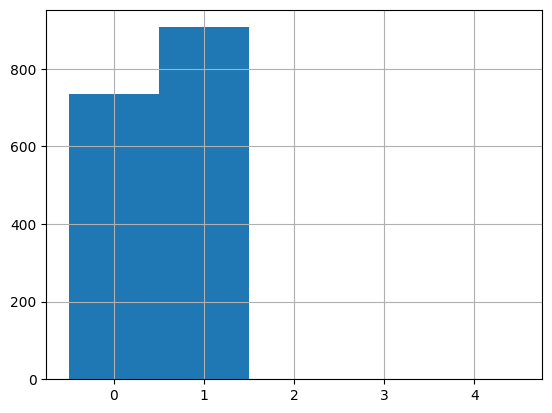

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [10]:
x_rdkitcdk = test_df.drop(columns=['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'GHS_category',
       'EPA_category', 'LD50_mgkg', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP'])

In [11]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

            CASRN          DTXSID  \
0      98119-87-0  DTXSID20243457   
849    85209-91-2   DTXSID2072914   
852   106065-10-5             nan   
855    19882-03-2             nan   
859      501-53-1   DTXSID9027158   
...           ...             ...   
932    64037-53-2             nan   
933     4095-32-3             nan   
934    62751-72-8  DTXSID30211824   
920    75530-68-6   DTXSID2046624   
1642   97817-39-5  DTXSID20243270   

                                                   Name     Structure_Source  \
0     Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...           EPA_DSSTox   
849   12H-Dibenzo[d,g][1,3,2]dioxaphosphocin, 2,4,8,...           EPA_DSSTox   
852                                                      Public_CrossChecked   
855                                                      Public_CrossChecked   
859                                Benzyl chloroformate           EPA_DSSTox   
...                                                 ...                  ..

In [12]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [13]:
x_test_rdkit_cdk

array([['182.3799214576036', '132.79999999999998', '430.4160000000001',
        ..., '6.08746284125034', '5.680000000000002', '0.0'],
       ['206.25761700245897', '55.760000000000005', '486.6330000000003',
        ..., '6.169925001442312', '9.204000000000002',
        '0.5862068965517241'],
       ['132.06146939593094', '53.99', '310.38999999999993', ...,
        '5.459431618637297', '2.564', '0.5882352941176471'],
       ...,
       ['206.32945098727976', '83.83000000000001', '491.92700000000013',
        ..., '6.247927513443585', '5.6240000000000006',
        '0.1481481481481481'],
       ['160.936165635433', '131.56', '385.3760000000001', ...,
        '5.857980995127573', '3.688', '0.3157894736842105'],
       ['115.25144196623931', '109.63', '282.37300000000005', ...,
        '5.321928094887363', '-0.984', '0.5454545454545454']],
      dtype=object)

In [14]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [15]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [16]:
import joblib

# Path fingerprint descriptor model
base_path_fp = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Oral\Model\Descriptor"

# Path physical chemical properties model
base_path_phys = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Oral\Model\Physiochemical"

# RF
rf_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_RF_morgan.pkl")
rf_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_RF_maccskey.pkl")
rf_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_RF_modred.pkl")
rf_phys   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_RF_phys.pkl")

# SVM
svm_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_SVM_morgan.pkl")
svm_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_SVM_maccskey.pkl")
svm_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_SVM_modred.pkl")
svm_phys   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_SVM_phys.pkl")

# XGB
xgb_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_XGB_morgan.pkl")
xgb_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_XGB_maccskey.pkl")
xgb_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_XGB_modred.pkl")
xgb_phys   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_XGB_phys.pkl")

# NN
nn_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_NN_morgan.pkl")
nn_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_NN_maccskey.pkl")
nn_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_NN_modred.pkl")
nn_phys   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_NN_phys.pkl")

# LGBM
lgbm_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_LGBM_morgan.pkl")
lgbm_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_LGBM_modred.pkl")
lgbm_phys   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_LGBM_phys.pkl")


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [18]:
test_df

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,rdkit_cdk
0,98119-87-0,DTXSID20243457,"Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...",EPA_DSSTox,OC(=O)C1=CC=CC=C1NC(=O)C(=CC1C=CC=CC=1)C(=O)NC...,?,InChI=1S/C24H18N2O6/c27-21(25-19-12-6-4-10-16(...,RNVMJUCFJAEWSG-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,5.0,0.5,9.0,1.0,132.79999999999998,6.08746284125034,5.680000000000002,0.0,"[182.3799214576036, 132.79999999999998, 430.41..."
849,85209-91-2,DTXSID2072914,"12H-Dibenzo[d,g][1,3,2]dioxaphosphocin, 2,4,8,...",EPA_DSSTox,CC(C)(C)C1=CC(=CC2CC3C=C(C=C(C=3OP(O)(=O)OC1=2...,[Na+],"InChI=1S/C29H43O4P/c1-26(2,3)20-14-18-13-19-15...",GGQHNQQPLWRNHD-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,3.0,0.5,4.0,1.0,65.57000000000001,6.169925001442312,9.204000000000002,0.5862068965517241,"[206.25761700245897, 55.760000000000005, 486.6..."
852,106065-10-5,nan,,Public_CrossChecked,COCCCOCC(C)OCCCOC(=O)C1C=CC=CC=1,?,InChI=1S/C17H26O5/c1-15(14-20-11-6-10-19-2)21-...,BEVNMDIBCATXFZ-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,15.0,0.4705882352941176,13.0,1.0,53.99,5.459431618637297,2.564,0.5882352941176471,"[132.06146939593094, 53.99, 310.38999999999993..."
855,19882-03-2,nan,,Public_CrossChecked,CCC12CCC3C(CCC4C=C(O)C=CC=43)C1CC(O)C2O,?,InChI=1S/C19H26O3/c1-2-19-8-7-14-13-6-4-12(20)...,KMVJBESLNMZCAQ-UHFFFAOYSA-N,FALSE,TRUE,...,2.0,2.0,0.5,1.0,0.0,60.69,5.643856189774724,4.2,0.6842105263157895,"[131.5408584026532, 60.69, 302.41399999999993,..."
859,501-53-1,DTXSID9027158,Benzyl chloroformate,EPA_DSSTox,O=C(Cl)OCC1C=CC=CC=1,?,InChI=1S/C8H7ClO2/c9-8(10)11-6-7-4-2-1-3-5-7/h...,HSDAJNMJOMSNEV-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,4.0,0.4285714285714285,3.0,0.0,26.3,4.459431618637298,2.3470000000000004,0.125,"[69.73962090472249, 26.3, 170.59500000000003, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,64037-53-2,nan,,Public_CrossChecked,CC(Br)C=CCl,?,"InChI=1S/C4H6BrCl/c1-4(5)2-3-6/h2-4H,1H3",JBFROCOYMZXIFP-UHFFFAOYSA-N,FALSE,FALSE,...,4.0,5.0,0.5,1.0,0.0,0.0,3.321928094887362,2.7300000000000004,0.5,"[51.315288171358155, 0.0, 169.449, 0, 0, 1, 0,..."
933,4095-32-3,nan,,Public_CrossChecked,CC(C)SSC(Cl)C(Cl)Cl,?,InChI=1S/C5H9Cl3S2/c1-3(2)9-10-5(8)4(6)7/h3-5H...,CCVBOQAQIZDRRY-UHFFFAOYSA-N,FALSE,FALSE,...,3.0,7.0,0.5,4.0,0.0,50.6,4.169925001442312,3.62,1.0,"[84.75500030314114, 0.0, 239.62, 2, 0, 4, 0, 2..."
934,62751-72-8,DTXSID30211824,"1H-Indole-3-acetic acid, 1-(p-chlorobenzoyl)-5...",EPA_DSSTox,CC1=C(CC(=O)OCOC(=O)C2C=CC=CC=2)C2=CC(=CC=C2N1...,?,InChI=1S/C27H22ClNO6/c1-17-22(15-25(30)34-16-3...,SPOHBRIBTFAVAK-UHFFFAOYSA-N,FALSE,FALSE,...,2.0,7.0,0.5,10.0,1.0,83.83000000000001,6.247927513443585,5.6240000000000006,0.1481481481481481,"[206.32945098727976, 83.83000000000001, 491.92..."
920,75530-68-6,DTXSID2046624,Nilvadipine,EPA_DSSTox,CC1NC(C#N)=C(C(C=1C(=O)OC(C)C)C1=CC(=CC=C1)[N+...,?,InChI=1S/C19H19N3O6/c1-10(2)28-19(24)15-11(3)2...,FAIIFDPAEUKBEP-UHFFFAOYSA-N,FALSE,FALSE,...,3.0,5.0,0.5,7.0,0.0,131.56,5.857980995127573,3.688,0.3157894736842105,"[160.936165635433, 131.56, 385.3760000000001, ..."


In [19]:
#physiochemical consensus here - only phys
#descriptor not yet included here!
# Predict with all phys models (RF, SVM, XGB, NN, LGBM)


#PHYSICOCHEMICAL CONSENSUS
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_phys_models(test_df):
    # Get probabilities from each phys model
    rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate mean probability across all phys models
    consensus_physicochemical_probs = np.mean(
        [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
        axis=0
    )

    # Convert mean probabilities to final class predictions (threshold = 0.5)
    final_predictions = (consensus_physicochemical_probs > 0.5).astype(int)

    return final_predictions, consensus_physicochemical_probs

# Run prediction
final_predictions, consensus_physicochemical_probs = predict_with_phys_models(test_df)
test_df['Phys_Predictions'] = final_predictions
test_df['Phys_Consensus_Probabilities'] = consensus_physicochemical_probs

y_true = test_df['Outcome'].astype(int)

# Evaluate performance
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, consensus_physicochemical_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[469 267]
 [152 755]]
Accuracy: 0.7449786975045648
AUC Score: 0.8093167273860313
F1 Score: 0.782789009849663
Sensitivity: 0.8324145534729879
Specificity: 0.6372282608695652
CCR (Correct Classification Rate): 0.7348214071712765
PPV (Positive Predictive Value): 0.738747553816047
NPV (Negative Predictive Value): 0.7552334943639292


In [ ]:
#individual descriptor

In [24]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan":   rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred":   rf_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[518 218]
 [208 699]]
Accuracy: 0.740718198417529
AUC: 0.8261124227026508
F1 Score: 0.7664473684210527
Sensitivity: 0.7706725468577729
Specificity: 0.7038043478260869
CCR: 0.7372384473419299
PPV (Precision): 0.7622682660850599
NPV: 0.7134986225895317

MACCSkey RF Performance
Confusion Matrix: [[489 247]
 [147 760]]
Accuracy: 0.7601947656725502
AUC: 0.8370621314893821
F1 Score: 0.7941483803552769
Sensitivity: 0.8379272326350606
Specificity: 0.6644021739130435
CCR: 0.751164703274052
PPV (Precision): 0.7547169811320755
NPV: 0.7688679245283019

Modred RF Performance
Confusion Matrix: [[518 218]
 [149 758]]
Accuracy: 0.7766281192939745
AUC: 0.862283387661186
F1 Score: 0.8050982474774296
Sensitivity: 0.8357221609702316
Specificity: 0.7038043478260869
CCR: 0.7697632543981592
PPV (Precision): 0.7766393442622951
NPV: 0.7766116941529235

CONSENSUS RF (Morgan + MACCSkey + Modred)
Confusion Matrix: [[505 231]
 [144 763]]
Accuracy: 0.7717589774802192
AUC: 0

In [25]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[509 227]
 [181 726]]
Accuracy: 0.7516737674984784
AUC: 0.8232002900148604
F1 Score: 0.7806451612903226
Sensitivity (Recall+): 0.8004410143329658
Specificity (Recall-): 0.6915760869565217
CCR: 0.7460085506447438
PPV (Precision): 0.7618048268625394
NPV: 0.7376811594202899

MACCS SVM Performance
Confusion Matrix: [[495 241]
 [158 749]]
Accuracy: 0.7571515520389531
AUC: 0.8395263589952544
F1 Score: 0.7896678966789668
Sensitivity (Recall+): 0.8257993384785005
Specificity (Recall-): 0.6725543478260869
CCR: 0.7491768431522937
PPV (Precision): 0.7565656565656566
NPV: 0.7580398162327718

Modred SVM Performance
Confusion Matrix: [[537 199]
 [178 729]]
Accuracy: 0.7705416920267802
AUC: 0.8432331863285556
F1 Score: 0.794550408719346
Sensitivity (Recall+): 0.8037486218302095
Specificity (Recall-): 0.7296195652173914
CCR: 0.7666840935238004
PPV (Precision): 0.7855603448275862
NPV: 0.7510489510489511

CONSENSUS SVM (Morgan + MACCS + Modred)
Confusion Matrix

In [26]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan":   xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred":   xgb_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")



Morgan XGB Performance
Confusion Matrix: [[499 237]
 [192 715]]
Accuracy: 0.7388922702373707
AUC: 0.8152338694214084
F1 Score: 0.7692307692307693
Sensitivity (Recall+): 0.7883131201764058
Specificity (Recall-): 0.6779891304347826
CCR: 0.7331511253055942
PPV (Precision): 0.7510504201680672
NPV: 0.7221418234442837

MACCSkey XGB Performance
Confusion Matrix: [[506 230]
 [165 742]]
Accuracy: 0.7595861229458308
AUC: 0.8413187287282489
F1 Score: 0.7897817988291644
Sensitivity (Recall+): 0.8180815876515987
Specificity (Recall-): 0.6875
CCR: 0.7527907938257994
PPV (Precision): 0.7633744855967078
NPV: 0.7540983606557377

Modred XGB Performance
Confusion Matrix: [[525 211]
 [174 733]]
Accuracy: 0.7656725502130249
AUC: 0.8494439384497388
F1 Score: 0.7920043219881145
Sensitivity (Recall+): 0.8081587651598677
Specificity (Recall-): 0.7133152173913043
CCR: 0.760736991275586
PPV (Precision): 0.7764830508474576
NPV: 0.7510729613733905

CONSENSUS XGB (Morgan + MACCS + Modred)
Confusion Matrix: [[522 2

In [27]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan":   nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS": nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred":   nn_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

for model_name, y_prob in probs.items():
    print(f"\n{model_name} NN Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\nCONSENSUS NN (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan NN Performance
Confusion Matrix: [[506 230]
 [203 704]]
Accuracy: 0.736457699330493
AUC: 0.8030483018551363
F1 Score: 0.7648017381857686
Sensitivity (Recall+): 0.7761852260198456
Specificity (Recall-): 0.6875
CCR: 0.7318426130099228
PPV (Precision): 0.7537473233404711
NPV: 0.7136812411847673

MACCS NN Performance
Confusion Matrix: [[474 262]
 [166 741]]
Accuracy: 0.73950091296409
AUC: 0.8014401874310917
F1 Score: 0.7759162303664922
Sensitivity (Recall+): 0.8169790518191842
Specificity (Recall-): 0.6440217391304348
CCR: 0.7305003954748095
PPV (Precision): 0.7387836490528414
NPV: 0.740625

Modred NN Performance
Confusion Matrix: [[ 38 698]
 [ 71 836]]
Accuracy: 0.5319537431527693
AUC: 0.4350582426537558
F1 Score: 0.6849651782056534
Sensitivity (Recall+): 0.9217199558985667
Specificity (Recall-): 0.051630434782608696
CCR: 0.4866751953405877
PPV (Precision): 0.5449804432855281
NPV: 0.3486238532110092

CONSENSUS NN (Morgan + MACCS + Modred)
Confusion Matrix: [[438 298]
 [129 778]]
A

In [28]:
# LGBM 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccs , lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs  = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs .n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan":   lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS ": lgbm_maccs .predict_proba(X_maccs )[:, 1],
        "Modred":   lgbm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs ,
    lgbm_modred
)

for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} LGBM Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCSkey + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan LGBM Performance =====
Confusion Matrix: [[554 182]
 [234 673]]
Accuracy: 0.7468046256847231
AUC: 0.8265228776185226
F1 Score: 0.7639046538024972
Sensitivity (Recall+): 0.7420066152149944
Specificity (Recall-): 0.7527173913043478
CCR: 0.7473620032596711
PPV (Precision): 0.7871345029239766
NPV: 0.7030456852791879

===== MACCS  LGBM Performance =====
Confusion Matrix: [[544 192]
 [195 712]]
Accuracy: 0.7644552647595861
AUC: 0.8401547744595177
F1 Score: 0.7863059083379348
Sensitivity (Recall+): 0.7850055126791621
Specificity (Recall-): 0.7391304347826086
CCR: 0.7620679737308853
PPV (Precision): 0.7876106194690266
NPV: 0.7361299052774019

===== Modred LGBM Performance =====
Confusion Matrix: [[510 226]
 [193 714]]
Accuracy: 0.7449786975045648
AUC: 0.8356577465126311
F1 Score: 0.7731456415809421
Sensitivity (Recall+): 0.7872105843439912
Specificity (Recall-): 0.6929347826086957
CCR: 0.7400726834763434
PPV (Precision): 0.7595744680851064
NPV: 0.7254623044096729

===== CONSENSUS

In [29]:
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK ALL MODEL CONSENSUS
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# FINAL CONSENSUS 
consensus_all_probs = all_model_probs.mean(axis=0)

# EVALUATION
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[521 215]
 [148 759]]
Accuracy: 0.7790626902008521
AUC: 0.8618444705431187
F1 Score: 0.8070175438596491
Sensitivity (Recall+): 0.836824696802646
Specificity (Recall-): 0.7078804347826086
CCR: 0.7723525657926273
PPV (Precision): 0.7792607802874744
NPV: 0.7787742899850523


In [30]:
# PHYSICOCHEMICAL + DESCRIPTOR

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function 
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK CONSENSUS PROBABILITIES
all_consensus_stack = np.vstack([
    consensus_physicochemical_probs,
    consensus_all_probs
])

# FINAL CONSENSUS (MEAN)
all_consensus_probs = all_consensus_stack.mean(axis=0)

# EVALUATION
all_consensus_metrics = evaluate_model(
    y_true,
    all_consensus_probs  
)

print("CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR")
for k, v in all_consensus_metrics.items():
    print(f"{k}: {v}")



CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR
Confusion Matrix: [[507 229]
 [134 773]]
Accuracy: 0.7790626902008521
AUC: 0.8641184506974737
F1 Score: 0.8098480880041907
Sensitivity (Recall+): 0.8522601984564498
Specificity (Recall-): 0.688858695652174
CCR: 0.7705594470543119
PPV (Precision): 0.7714570858283433
NPV: 0.7909516380655226


In [ ]:
#read accross

In [31]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Buat fingerprint dari test set (Morgan misalnya)
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# Probabilitas prediksi untuk semua test (leave-one-out)
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# Konversi ke prediksi biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6962872793670115
AUC: 0.7582390585302718
F1 Score: 0.7292457948996202
Sensitivity (Recall+): 0.74090407938258
Specificity (Recall-): 0.6413043478260869
CCR: 0.6911042136043335
PPV (Precision): 0.717948717948718
NPV: 0.6676096181046676


In [32]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# PHYSICOCHEMICAL CONSENSUS
rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6962872793670115
AUC: 0.7582390585302718
F1 Score: 0.7292457948996202
Sensitivity (Recall+): 0.74090407938258
Specificity (Recall-): 0.6413043478260869
CCR: 0.6911042136043335
PPV (Precision): 0.717948717948718
NPV: 0.6676096181046676

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[521 215]
 [148 759]]
Accuracy: 0.7790626902008521
AUC: 0.8618444705431187
F1 Score: 0.8070175438596491
Sensitivity (Recall+): 0.836824696802646
Specificity (Recall-): 0.7078804347826086
CCR: 0.7723525657926273
PPV (Precision): 0.7792607802874744
NPV: 0.7787742899850523

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.7449786975045648
AUC: 0.8093167273860313
F1 Score: 0.782789009849663
Sensitivity (Recall+): 0.8324145534729879
Specificity (Recall-): 0.6372282608695652
CCR: 0.7348214071712765
PPV (Precision): 0.738747553816047
NPV: